In [13]:
from helpers import *

import os
import re
import numpy as np
import matplotlib. pyplot as plt
from scipy.spatial.distance import directed_hausdorff

In [14]:
nubmer_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
n_runs= [10]

In [15]:
def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    tolerance = 1/num_points
    return tolerance
    
def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points

In [16]:
def KS_Test(data, algo):
    
    # Perform K-S test
    ks_statistic, p_value = stats.kstest(data, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)
    
    print("********START********")
    # Display the results
    print("******KS-Test for {}".format(algo),"*********")
    print(f"K-S Statistic: {ks_statistic}")
    print(f"P-Value: {p_value}")

    # Decision based on the p-value
    alpha = 0.05
    if p_value > alpha:
        print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
    else:
        print("Reject the null hypothesis: The sample does not follow the uniform distribution.")
    
    print("********END********")

In [17]:
import os

def list_txt_files_in_directory(directory_path):
    files_and_directories = os.listdir(directory_path)
    txt_files = [file for file in files_and_directories if file.endswith('.txt')]
    txt_files = [file for file in txt_files if '.txt' in file]
    txt_files.sort()
    txt_files= [directory_path+"/"+file for file in txt_files]
        
    return txt_files

In [18]:
eps_t= 1e-5
def get_accuracy(setXYP):
    acc= 0.0
    for i in range(len(setXYP)):
        if (0.5 <= setXYP[i][0] <=1.0 and (1-setXYP[i][0]-setXYP[i][1])<eps_t)== True:
            acc+= 1
    return (acc/len(setXYP))*100

In [19]:
n_times= 10
def get_values(folders):
    dist_= []
    avg_hd= []
    accuracy_list= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]

        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            res_solns.extend(solns.tolist())

        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        t_values = np.random.uniform(0.5, 1, len(distinct_points))

        points = np.column_stack((t_values, 1 - t_values))
        

        print(len(distinct_points), len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        accuracy_list.append(get_accuracy(distinct_points))
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')    
    ax1.set_ylabel('Perentage of distint points',color='blue')
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])
    #plt.savefig('../GSM/solns_runs/Ex1/plot_ex1.png')
    plt.grid(True)
    plt.show()

    return dist_,avg_hd,accuracy_list

In [20]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        res= []
        for file in files:
            solns= np.genfromtxt(file, delimiter=',')
            res.extend(solns.tolist())
    
        res= np.array(res)
        num, distinct_points= count_repeated_points(res)
            
        all_solns.append(distinct_points)
        
    
    
    for i in range(len(all_solns)):
        print("Plot for {} points".format(nubmer_points_list[i]))
        plt.scatter(np.array(all_solns[i])[:,0], np.array(all_solns[i])[:,1], c= 'black')
        plt.xlim([0,1])
        plt.ylim([0,1])
        plt.grid(True)
        plt.show()

In [21]:
def partition_interval(a, b, n):
#     n= n-1
    interval_length = b - a
    partition_width = interval_length / n
    partition_points = [a + i * partition_width for i in range(n + 1)]
    return partition_points

def count_values_in_bins(values, bins):
    # Initialize a dictionary to store the counts for each bin
    bin_counts = {bin_index: 0 for bin_index in range(len(bins) - 1)}

    # Iterate over each value
    for value in values:
        # Find the bin that the value falls into
        bin_index = 0
        while bin_index < len(bins) - 1 and not (bins[bin_index] <= value < bins[bin_index + 1]):
            bin_index += 1

        # Increment the count for the corresponding bin.
        if bin_index < len(bins) - 1:
            bin_counts[bin_index] += 1

    return bin_counts

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.distributions.empirical_distribution import ECDF


# -------------------------
# 2. Define uniform parameters
# -------------------------
a1, b1 = 0.5, 1      # x1 ~ Uniform(0.5, 1)
a2, b2 = 0, 0.5      # x2 ~ Uniform(0, 0.5)

def plot_ecdf_vs_uniform(sample, a, b, coord_name):
    ecdf = ECDF(sample)
    x_sorted = np.sort(sample)
    cdf_uniform = (x_sorted - a) / (b - a)  # Uniform CDF formula

    plt.figure(figsize=(5,3))
    plt.plot(ecdf.x, ecdf.y, marker='.', linestyle='none', label='Empirical CDF', c='blue')
    # plt.plot(x_sorted, cdf_uniform, 'r--', label=f'Uniform({a},{b}) CDF')
    plt.plot([a, b], [0.0, 1], 'r--', label='Uniform CDF')
    plt.xlabel(f'{coord_name} values')
    plt.ylabel('CDF')
    plt.title(f'Empirical CDF vs Uniform CDF ({coord_name})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



# -------------------------
# 5. Perform K-S test for each coordinate
# -------------------------
def ks_test(sample, a, b, coord_name, alpha=0.05):
    ks_statistic, p_value = stats.kstest(sample, "uniform", args=(a, b-a))
    print(f"--- {coord_name} ---")
    print(f"K-S Statistic: {ks_statistic:.4f}")
    print(f"P-Value: {p_value:.4f}")
    if p_value > alpha:
        print(f"Result: Fail to reject H0 → Sample follows Uniform({a},{b})\n")
    else:
        print(f"Result: Reject H0 → Sample does NOT follow Uniform({a},{b})\n")

In [23]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        res= []
        for file in files:
            solns= np.genfromtxt(file, delimiter=',')
#             num, distinct_points,_ = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
            res.extend(solns.tolist())
    
        res= np.array(res)
        num, distinct_points= count_repeated_points(res)
#         distinct_points= np.array(distinct_points)
            
        all_solns.append(distinct_points)
    return all_solns


# EIA

In [24]:
def extract_number(s):
    return int(re.search(r'\d+', s).group())

def list_subfolders(folder_path):
    subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
    sorted_subfolders = sorted(subfolders, key=lambda x: int(x.split("_")[-1]))
    return sorted_subfolders


def list_txt_files(folder_path):
    txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
#     txt_files = sorted(txt_files, key=lambda x: int(x.split("_")[2]))
    return txt_files

## Number of starting points vs. PDP and HD

In [25]:
n_times= 10
def get_values(folders):
    dist_= []
    avg_hd= []
    accuracy_list= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]
        #print(directory_path)

        files= list_txt_files_in_directory(directory_path)
        
        files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]

#         t_values = np.random.uniform(0.5, 1, num_points)

#         points = np.column_stack((t_values, 1 - t_values))
        
        res_solns= []

        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',') #[:,:-1]
            
            res_solns.extend(solns.tolist())
            
#             num, distinct_points,_ = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
                        
#             res_solns.extend(distinct_points.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        print(len(distinct_points), len(res_solns))
        
        # Get HD:
        t_values = np.random.uniform(0.5, 1, len(distinct_points))

        points = np.column_stack((t_values, 1 - t_values))
        

#         print(points.shape, distinct_points.shape)
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        accuracy_list.append(get_accuracy(distinct_points))
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    #plt.savefig('../EIA/solns_runs/Ex1/plot_ex1.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd,accuracy_list

In [26]:
percents= [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

Running for p=  100
999 1000
1999 2000
2996 3000
3998 4000
4998 5000
5999 6000
7000 7000
7999 8000
8999 9000
9998 10000
10999 11000
12000 12000
13000 13000
13999 14000
14998 15000


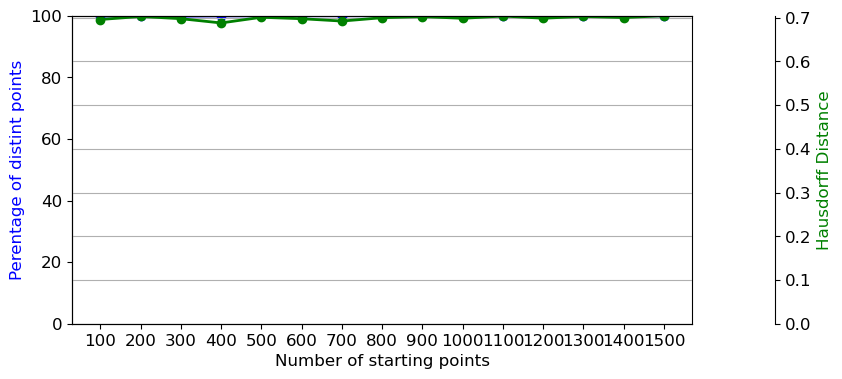

Running for p=  90
335 1000
730 2000
1113 3000
1475 4000
1864 5000
2227 6000
2639 7000
3015 8000
3383 9000
3733 10000
4145 11000
4522 12000
4903 13000
5311 14000
5684 15000


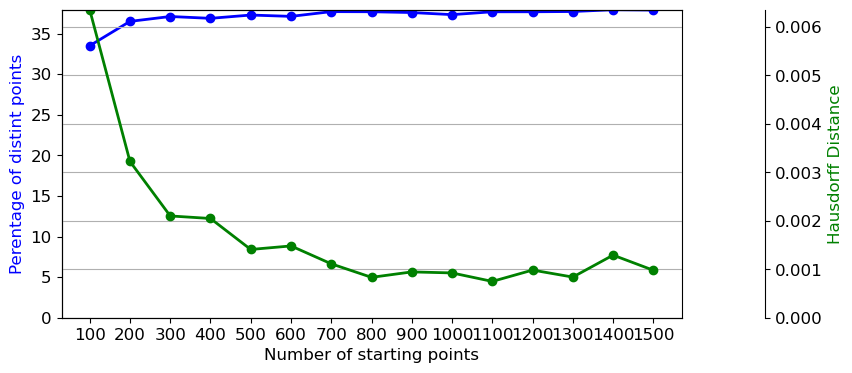

Running for p=  80
345 1000
731 2000
1089 3000
1511 4000
1883 5000
2261 6000
2635 7000
2993 8000
3365 9000
3780 10000
4142 11000
4532 12000
4909 13000
5302 14000
5678 15000


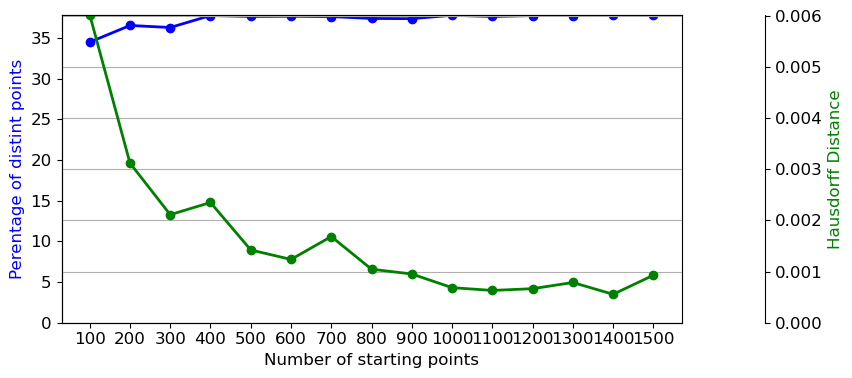

Running for p=  70
337 1000
733 2000
1114 3000
1469 4000
1836 5000
2256 6000
2638 7000
2979 8000
3368 9000
3747 10000
4156 11000
4539 12000
4894 13000
5407 14000
5714 15000


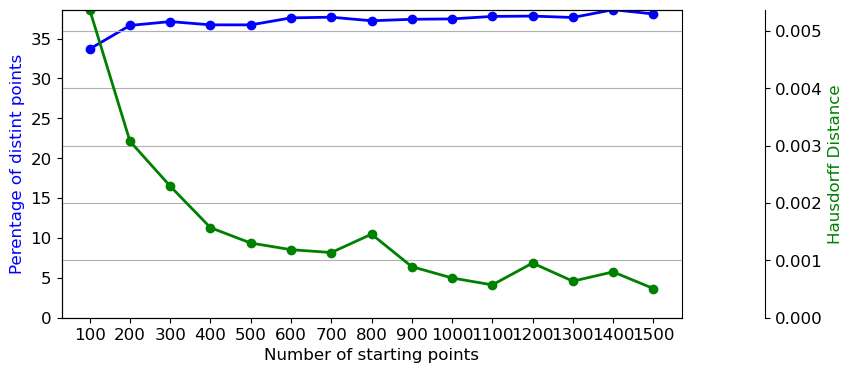

Running for p=  60
339 1000
718 2000
1100 3000
1481 4000
1872 5000
2220 6000
2629 7000
3022 8000
3423 9000
3742 10000
4176 11000
4571 12000
4902 13000
5316 14000
5719 15000


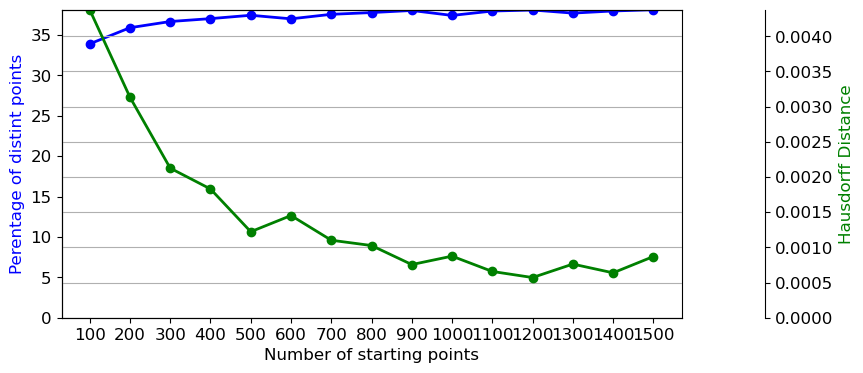

Running for p=  50
343 1000
717 2000
1086 3000
1447 4000
1850 5000
2246 6000
2635 7000
2979 8000
3387 9000
3747 10000
4147 11000
4567 12000
4874 13000
5262 14000
5709 15000


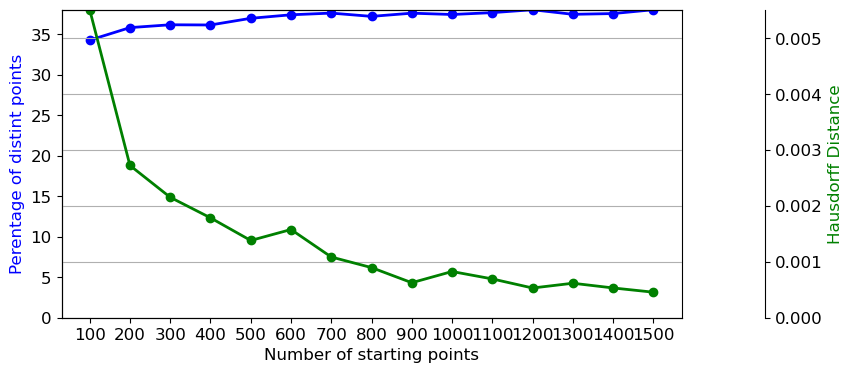

Running for p=  40
308 1000
701 2000
1074 3000
1485 4000
1808 5000
2226 6000
2590 7000
2982 8000
3408 9000
3741 10000
4179 11000
4567 12000
4910 13000
5291 14000
5675 15000


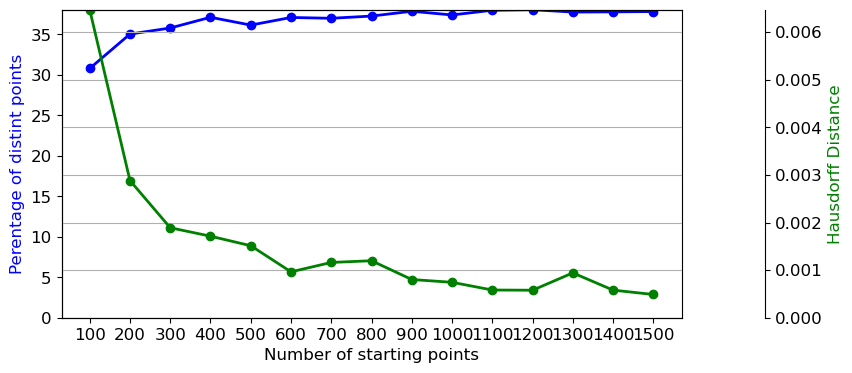

Running for p=  30
304 1000
654 2000
1062 3000
1443 4000
1810 5000
2251 6000
2606 7000
2970 8000
3337 9000
3712 10000
4087 11000
4488 12000
4900 13000
5279 14000
5678 15000


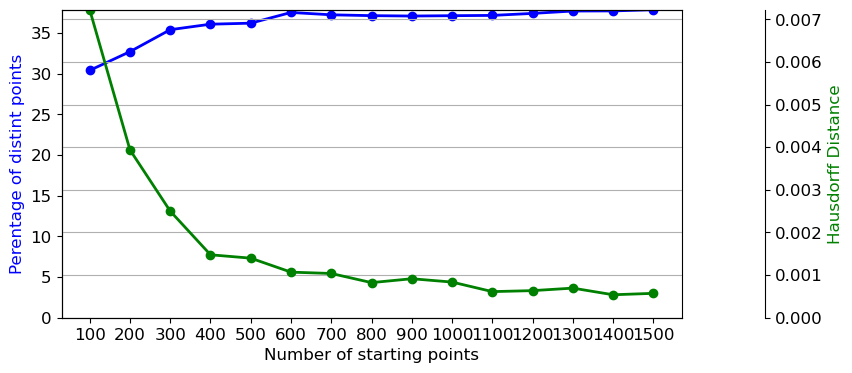

Running for p=  20
274 1000
633 2000
1040 3000
1353 4000
1749 5000
2172 6000
2516 7000
2929 8000
3295 9000
3746 10000
4124 11000
4449 12000
4832 13000
5250 14000
5599 15000


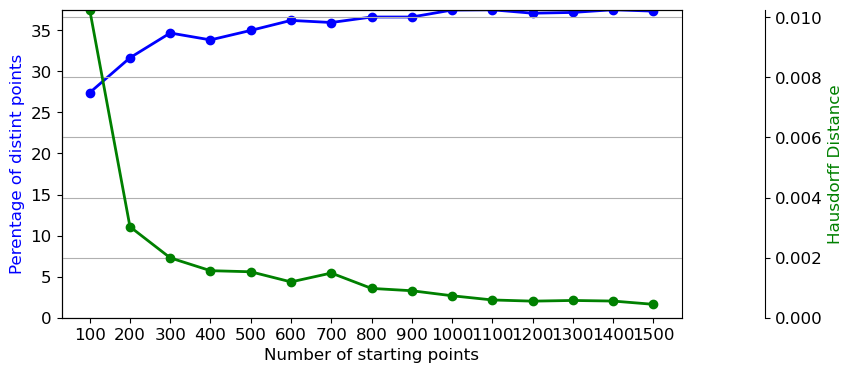

Running for p=  10
182 1000
533 2000
856 3000
1252 4000
1645 5000
2029 6000
2357 7000
2763 8000
3230 9000
3614 10000
3971 11000
4336 12000
4718 13000
5143 14000
5545 15000


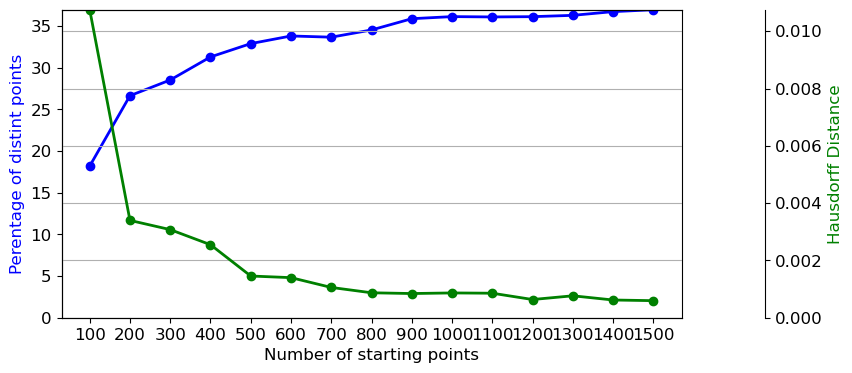

In [27]:
Ex1Res= {10: {
    "pdp": None, "hd": None,
}, 20: {
    "pdp": None, "hd":None,
}, 30: {
    "pdp": None, "hd": None, 
}, 40: {
    "pdp": None, "hd": None, 
}
, 50: {
    "pdp": None, "hd": None, 
}
, 60: {
    "pdp": None, "hd": None, 
}
, 70: {
    "pdp": None, "hd": None, 
}
, 80: {
    "pdp": None, "hd": None, 
}
, 90: {
    "pdp": None, "hd": None, 
}
, 100: {
    "pdp": None, "hd": None, 
}
}

# for p in range(len(percents)):
for p in range(len(percents)-1, -1, -1):
    print("Running for p= ", percents[p])
    main_path = "./percent/"+str(percents[p])+"/Ex1/"
    subfolders = list_subfolders(main_path)

        
    txt_files = list_subfolders(subfolders[0])
    # list_txt_files(subfolders[0])

    titles = [str(100*i) for i in range(1, 16)]

    colors = [
        'blue', 'orange', 'r', 'yellow', 'purple',
        'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
        'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
    ]

    folders= ["./percent/"+str(percents[p])+"/Ex1/N_{}/".format(str(pt)) for pt in nubmer_points_list]
    pdpeia, hdeia, accuracyeia= get_values(folders)
    Ex1Res[percents[p]]["pdp"]= pdpeia
    Ex1Res[percents[p]]["hd"]= hdeia

In [28]:
Ex1Res

{10: {'pdp': [18.2,
   26.650000000000002,
   28.53333333333333,
   31.3,
   32.9,
   33.81666666666667,
   33.67142857142857,
   34.5375,
   35.888888888888886,
   36.14,
   36.1,
   36.13333333333333,
   36.29230769230769,
   36.73571428571429,
   36.96666666666666],
  'hd': [0.01074967800259925,
   0.003396629756649488,
   0.0030749656639941308,
   0.0025482254789664562,
   0.0014556348396645678,
   0.0013988382579690148,
   0.0010567489979813702,
   0.0008706140799139046,
   0.0008439319873210621,
   0.0008650380267660002,
   0.0008552410847642234,
   0.0006353271682846287,
   0.0007653193339932392,
   0.0006185723901391054,
   0.0005951696690043094]},
 20: {'pdp': [27.400000000000002,
   31.65,
   34.66666666666667,
   33.825,
   34.98,
   36.199999999999996,
   35.94285714285714,
   36.6125,
   36.611111111111114,
   37.46,
   37.49090909090909,
   37.075,
   37.16923076923077,
   37.5,
   37.32666666666667],
  'hd': [0.010251893121614572,
   0.003028289209287033,
   0.0019923378

In [29]:
import json
import numpy as np

def convert(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    raise TypeError(f"Type {type(obj)} not serializable")

with open("Ex1EIA.json", "w") as f:
    json.dump(Ex1Res, f, default=convert)

## Plot

In [30]:
import json

# Load the JSON file
with open("Ex1EIA.json", "r") as f:  # replace "data.json" with your file name
    res = json.load(f)

# Convert keys to integers (optional, makes plotting easier)
res = {int(k): v for k, v in res.items()}

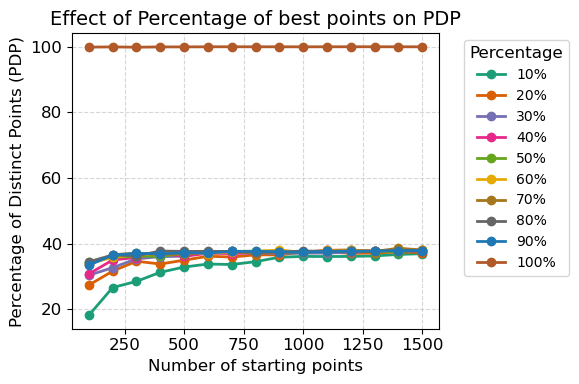

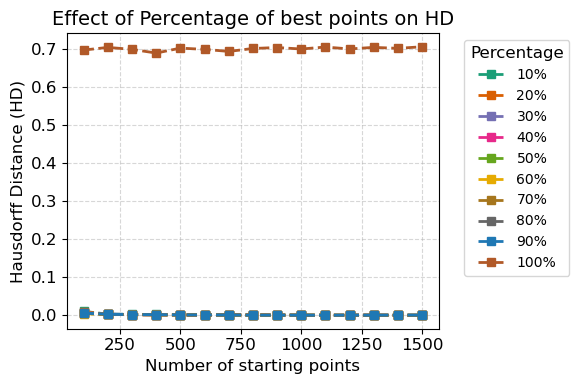

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Data
points = np.arange(100, 1600, 100)
keys = sorted(res.keys())  # ensures percentages are in order

# Publication-style settings
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "lines.markersize": 6
})

# Choose a good perceptual colormap
# colors = plt.cm.viridis(np.linspace(0, 1, len(keys)))
colors = [
    '#1b9e77',  # greenish
    '#d95f02',  # orange
    '#7570b3',  # purple
    '#e7298a',  # pink/magenta
    '#66a61e',  # lime green
    '#e6ab02',  # yellow-orange
    '#a6761d',  # brown
    '#666666',  # gray
    '#1f78b4',  # blue
    '#b15928',  # reddish brown
]

# ---- PDP Plot ----
fig, ax = plt.subplots(figsize=(6,4))
for i, p in enumerate(keys):
    ax.plot(points, res[p]["pdp"], marker='o', linestyle='-', color=colors[i], label=f'{p}%')
ax.set_xlabel('Number of starting points')
ax.set_ylabel('Percentage of Distinct Points (PDP)')
ax.set_title('Effect of Percentage of best points on PDP')
ax.grid(True, linestyle='--', alpha=0.5)

# Adaptive legend: outside if many lines, inside if few
if len(keys) > 6:
    ax.legend(title='Percentage', bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    ax.legend(title='Percentage', loc='best')

plt.tight_layout()
plt.savefig("Ex1PDP_vs_p.png", dpi=300, bbox_inches='tight')
plt.show()

# ---- HD Plot ----
fig, ax = plt.subplots(figsize=(6,4))
for i, p in enumerate(keys):
    ax.plot(points, res[p]["hd"], marker='s', linestyle='--', color=colors[i], label=f'{p}%')
ax.set_xlabel('Number of starting points')
ax.set_ylabel('Hausdorff Distance (HD)')
ax.set_title('Effect of Percentage of best points on HD')
ax.grid(True, linestyle='--', alpha=0.5)

# Adaptive legend
if len(keys) > 6:
    ax.legend(title='Percentage', bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    ax.legend(title='Percentage', loc='best')

plt.tight_layout()
plt.savefig("Ex1HD_vs_p.png", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# for (p,h,acc) in zip(pdpeia,hdeia, accuracyeia):
#     print(p, " * ", h, " * ", acc)